# Ontología y Metadatos Estructurados del Dominio Deportivo
## Capa de enriquecimiento para el buscador semántico híbrido

**Universidad del Norte** · División de Ciencias Básicas
**Proyecto de grado:** Escalando la búsqueda semántica en plataformas GovTech
**Autor:** Luis David Peñaranda Pérez — Estudiante de Pregrado en Ciencia de Datos
**Asesor:** Diego Armando Ramírez Hernández, M.Sc.

---

**Resumen.** El cuaderno `EDA_SUID.ipynb` ya respondió *qué reportes se
piden y con qué frecuencia*. Este documento parte de esos resultados —no
los repite— para responder una pregunta distinta y conceptual: **¿qué
entidades de negocio, qué relaciones entre ellas y qué conceptos de
búsqueda deben quedar codificados como metadatos, para que el buscador
semántico pueda tanto entender el significado de una pregunta como
resolver búsquedas exactas por nombre propio?**

Esta última parte es central para este documento: un usuario debe poder
escribir el nombre de un deportista o de una institución (por ejemplo,
"Andrés Torres" o el nombre de un colegio) y obtener resultados
relevantes, algo que un modelo puramente semántico no garantiza bien —los
modelos dan buenos resultados con el significado de una frase, pero
tienden a fallar con nombres propios exactos—. Este es exactamente el
caso que la propuesta de la monografía (capítulo de propuesta, hipótesis
C1) identifica como el punto fuerte de un sistema **híbrido**: la
combinación de búsqueda léxica exacta con búsqueda semántica. Este
cuaderno construye la pieza de datos —la ontología y los metadatos— que
hace posible esa combinación.

**Insumos que se reutilizan** (generados por `EDA_SUID.ipynb`, no se
vuelven a calcular aquí):
- `tabla_maestra_reportes.json` — 17 reportes, con su prioridad de
  indexación y descripción semántica.
- `suid_query_signatures.json` — las columnas reales proyectadas y
  filtradas en cada patrón de consulta observado.
- El diccionario de nombres amigables, reconstruido aquí de forma
  idéntica para mantener consistencia entre ambos documentos.

**Lo que este cuaderno NO hace:** no repite ningún análisis de frecuencia,
demanda o volumen (ya resuelto). El foco es exclusivamente conceptual y de
modelado de datos.


## 1. Objetivos

1. Identificar las **entidades de negocio** centrales del dominio deportivo.
2. Determinar los **atributos** reales de cada entidad, con evidencia
   directa de las columnas que de verdad se proyectan y filtran en los
   reportes más solicitados.
3. Mapear las **relaciones** entre entidades.
4. Priorizar los **conceptos de búsqueda** que un usuario escribiría en
   lenguaje natural — con énfasis explícito en la búsqueda por **nombre
   propio de una persona o de una institución**.
5. Proponer una **ontología ligera** (clases, propiedades de datos,
   propiedades de relación) exportable en formato YAML.
6. Generar, para los reportes de prioridad Alta y Media, un bloque de
   **metadatos estructurados** listo para inyectar en el pipeline del
   buscador.
7. Recomendar, con precisión, en qué punto del pipeline (indexación,
   *ranking*, filtros) debe usarse cada pieza de esta capa.


**Mapa general de este cuaderno.** El siguiente diagrama resume cómo
se conecta cada sección con la siguiente, desde los insumos del EDA hasta
la inyección final en el buscador.

![Mapa general del cuaderno](../images/diagramas/diagrama_1_mapa_general.png)

<details><summary>Fuente Mermaid de este diagrama (por si se quiere editar o re-renderizar)</summary>

```{mermaid}
flowchart TD
    A["Insumos del EDA anterior<br/>tabla_maestra_reportes.json<br/>suid_query_signatures.json"] --> B["Sección 3<br/>Columnas reales por reporte"]
    B --> C["Sección 4<br/>Catálogo de 12 entidades de negocio"]
    C --> D["Sección 5<br/>Mapa de 15 relaciones"]
    C --> E["Sección 6<br/>Conceptos de búsqueda priorizados"]
    D --> F["Sección 7<br/>Ontología ligera (YAML)"]
    E --> F
    F --> G["Sección 8<br/>Metadatos por reporte (JSON)"]
    G --> H["Sección 9<br/>Inyección en el buscador híbrido"]

    classDef default fill:#00529B,color:#fff,stroke:#122C52,stroke-width:1px;
```

</details>


## 2. Configuración y carga de los insumos del EDA anterior

In [1]:
import json
import re
import yaml
from pathlib import Path
from collections import Counter, defaultdict

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

AZUL = "#00529B"
AZUL_OSC = "#122C52"
NARANJA = "#F18520"
NARANJA_CLARO = "#FDECDC"
GRIS_BORDE = "#CED5DF"

DATA_DIR = Path("../data/athena_suid")
ONTO_DIR = Path("../data/ontologia_suid")
ONTO_DIR.mkdir(parents=True, exist_ok=True)

with open(DATA_DIR / "tabla_maestra_reportes.json", encoding="utf-8") as f:
    tabla_maestra = pd.DataFrame(json.load(f))

with open(DATA_DIR / "suid_query_signatures.json", encoding="utf-8") as f:
    firmas_raw = json.load(f)["firmas"]

print(f"Reportes cargados desde la tabla maestra: {len(tabla_maestra)}")
print(f"Firmas de consulta cargadas: {len(firmas_raw)}")
tabla_maestra[["reporte", "prioridad_de_indexacion", "frecuencia_datos"]].head(6)


Reportes cargados desde la tabla maestra: 17
Firmas de consulta cargadas: 744


,reporte,prioridad_de_indexacion,frecuencia_datos
0,Reporte de Promoción de Deportistas,Alta,4295
1,Reporte de Grupos,Alta,1445
2,Reporte de Personal de Apoyo,Alta,965
3,Reporte de Documentación de Deportistas,Alta,592
4,Reporte de Participación,Alta,532
5,Reporte Individual de Deportistas,Media,397


### 2.1 Diccionario de nombres amigables

Se reconstruye de forma idéntica al usado en `EDA_SUID.ipynb`, para que
ambos documentos hablen exactamente el mismo lenguaje.

In [2]:
NOMBRE_AMIGABLE = {
    "individual_athletes_report":                 "Reporte Individual de Deportistas",
    "groups_report":                               "Reporte de Grupos",
    "support_staff_report":                        "Reporte de Personal de Apoyo",
    "athlete_documentation_report":                "Reporte de Documentación de Deportistas",
    "promotions_log":                              "Registro de Promociones",
    "phases":                                      "Fases del Evento",
    "participants_report":                         "Reporte de Participantes",
    "participation_intent_report":                 "Reporte de Intención de Participación",
    "participation_intent_changes_report":         "Reporte de Cambios en la Intención de Participación",
    "participation_intent_delegations_report":     "Reporte de Delegaciones de Participación",
    "institutions_report":                         "Reporte de Instituciones",
    "institutions_summary":                        "Resumen de Instituciones",
    "progress_metrics":                            "Métricas de Progreso",
    "goal_achievements":                           "Cumplimiento de Metas",
    "region_progress":                             "Progreso por Región",
    "dashboard_summary":                           "Resumen del Tablero de Control",
    "user_distribution":                           "Distribución de Usuarios",
    "federation_sport_metrics":                    "Métricas por Federación Deportiva",
    "pruebas_caidas":                               "Pruebas de Caídas",
    "pruebas_caidas_resumen":                       "Resumen de Pruebas de Caídas",
    "pruebas_caidas_todas_etapas":                  "Pruebas de Caídas — Todas las Etapas",
    "pruebas_caidas_todas_etapas_resumen":          "Resumen de Pruebas de Caídas — Todas las Etapas",
}

# Correspondencia entre los nombres de reporte del archivo de firmas (v1,
# generado antes de introducir nombres amigables) y los nombres ya
# amigables de la tabla maestra (v2). Dos firmas de v1 (promotions_log,
# phases) colapsan en un solo reporte de v2 (Promoción de Deportistas).
V1_A_V2 = {
    "Reporte de promoción / avance de atletas por etapa": "Reporte de Promoción de Deportistas",
    "Reporte sobre promotions_log": "Reporte de Promoción de Deportistas",
    "Reporte sobre phases": "Reporte de Promoción de Deportistas",
    "Reporte de grupos": "Reporte de Grupos",
    "Reporte de personal de apoyo": "Reporte de Personal de Apoyo",
    "Reporte de documentación de atletas": "Reporte de Documentación de Deportistas",
    "Reporte de participación / intención de participación": "Reporte de Participación",
    "Listado / reporte de atletas individuales": "Reporte Individual de Deportistas",
    "Reporte sobre dashboard_summary": "Reporte sobre Resumen del Tablero de Control",
    "Reporte de instituciones": "Reporte de Instituciones",
    "Métricas de progreso / cumplimiento de metas": "Reporte de Progreso y Cumplimiento de Metas",
    "Reporte sobre user_distribution": "Reporte sobre Distribución de Usuarios",
    "Reporte sobre federation_sport_metrics": "Reporte sobre Métricas por Federación Deportiva",
    "Reporte sobre pruebas_caidas_todas_etapas": "Reporte sobre Pruebas de Caídas — Todas las Etapas",
    "Reporte sobre participation_intent_changes_report": "Reporte de Cambios en la Intención de Participación",
    "Reporte sobre participation_intent_delegations_report": "Reporte de Delegaciones de Participación",
    "Reporte sobre pruebas_caidas": "Reporte sobre Pruebas de Caídas",
    "Reporte sobre pruebas_caidas_resumen": "Reporte sobre Resumen de Pruebas de Caídas",
    "Reporte sobre pruebas_caidas_todas_etapas_resumen": "Reporte sobre Resumen de Pruebas de Caídas — Todas las Etapas",
}

def amigable(t):
    return NOMBRE_AMIGABLE.get(t, t.replace("_", " ").capitalize())

print("Diccionario y correspondencia de nombres listos:",
      len(NOMBRE_AMIGABLE), "tablas,", len(V1_A_V2), "reportes v1 mapeados.")


Diccionario y correspondencia de nombres listos: 22 tablas, 19 reportes v1 mapeados.


## 3. Qué columnas se usan realmente en cada reporte

No se vuelve a analizar frecuencia: se reutiliza la lista de columnas ya
extraída en `EDA_SUID.ipynb` para cada patrón de consulta
(`suid_query_signatures.json`), y simplemente se agrega por reporte. Esto
da una base **empírica** —no inventada— sobre qué atributos tiene cada
entidad, en la Sección 5.

In [3]:
columnas_por_reporte = defaultdict(Counter)
for firma in firmas_raw:
    nombre_v2 = V1_A_V2.get(firma["nombre_logico"])
    if not nombre_v2:
        continue
    for col in firma.get("columnas_clave", []):
        columnas_por_reporte[nombre_v2][col] += firma["frecuencia"]

for reporte, contador in list(columnas_por_reporte.items())[:2]:
    print(f"--- {reporte} ---")
    print(contador.most_common(10))
    print()


--- Reporte de Promoción de Deportistas ---
[('inst_department_name', 2069), ('inst_municipality_name', 2028), ('document_number', 1992), ('full_name', 1968), ('institution_name', 1963), ('inst_region_name', 1849), ('institution_dane_code', 1848), ('document_type_name', 1836), ('email', 1816), ('first_last_name', 1815)]

--- Reporte de Grupos ---
[('institution_name', 657), ('current_stage', 648), ('inst_municipality_name', 611), ('inst_department_name', 596), ('group_name', 594), ('category_name', 593), ('institution_dane_code', 593), ('group_status', 592), ('dependency', 591), ('discipline_name', 591)]



## 4. Identificación de entidades de negocio

A partir de las columnas observadas en la Sección 3 y del conocimiento de
dominio ya documentado en el caso de estudio del EDA anterior, se agrupan
las columnas en **12 entidades de negocio**. Cada columna se asigna a la
entidad a la que describe conceptualmente (no a la tabla técnica de la
que proviene, que puede ser distinta).

**Nota sobre nombres propios.** Dos entidades —**Deportista** e
**Institución**— tienen un atributo marcado explícitamente como *nombre
propio de búsqueda exacta* (`full_name` e `institution_name`,
respectivamente). Esto es intencional: son los campos que deben resolver
una búsqueda literal como "Andrés Torres" o el nombre de un colegio.

In [4]:
# Mapa columna técnica -> entidad de negocio. Es un mapa de modelado
# (juicio de dominio), pero cada columna que aparece aquí fue observada
# realmente en las consultas (Sección 3), no inventada.
COLUMNA_A_ENTIDAD = {
    # --- Deportista ---
    "full_name": "Deportista", "first_name": "Deportista", "second_name": "Deportista",
    "first_last_name": "Deportista", "second_last_name": "Deportista",
    "document_type": "Deportista", "document_type_name": "Deportista", "document_number": "Deportista",
    "birth_date": "Deportista", "sex_code": "Deportista", "sex_name": "Deportista",
    "email": "Deportista", "phone_number": "Deportista", "nationality": "Deportista",
    "nationality_name": "Deportista", "ethnicity_code": "Deportista", "ethnicity_name": "Deportista",
    "disability_code": "Deportista", "disability_name": "Deportista",
    "conflict_victim_type_code": "Deportista", "conflict_victim_type_name": "Deportista",
    "sexual_orientation_code": "Deportista", "sexual_orientation_name": "Deportista",
    "indigenous_community_code": "Deportista", "indigenous_community_name": "Deportista",
    "gender_identity_code": "Deportista", "gender_identity_name": "Deportista",
    "uniform_size": "Deportista", "school_grade": "Deportista", "user_code": "Deportista",
    "height": "Deportista", "weight": "Deportista", "blood_type": "Deportista",
    "address": "Deportista", "emergency_contact_name": "Deportista",
    "emergency_contact_phone": "Deportista", "emergency_contact_relationship": "Deportista",
    "children_protection": "Deportista", "is_reinforcement": "Deportista",
    # --- Institución ---
    "institution_name": "Institución", "institution_dane_code": "Institución",
    "inst_department_code": "Institución", "inst_department_name": "Institución",
    "inst_municipality_code": "Institución", "inst_municipality_name": "Institución",
    "inst_region_name": "Institución",
    # legal_name es el nombre propio real de la institución en el Reporte
    # de Instituciones (nombre técnico distinto al usado en otros reportes,
    # detectado al agregar las columnas reales observadas, Sección 3).
    "legal_name": "Institución", "organization_code": "Institución",
    "dane_code": "Institución", "company_type_name": "Institución",
    # --- Grupo ---
    "group_name": "Grupo", "group_status": "Grupo", "total_athletes": "Grupo",
    "total_support_staff": "Grupo",
    # --- Evento ---
    "event_code": "Evento", "event_name": "Evento", "event_slug": "Evento",
    "event_status": "Evento", "event_sub_status": "Evento",
    "event_start_date": "Evento", "event_end_date": "Evento",
    "event_registration_end_date": "Evento", "event_phases_count": "Evento",
    # --- Etapa / Fase ---
    "current_stage": "Etapa/Fase", "stage_sequence": "Etapa/Fase",
    "discipline_status": "Etapa/Fase",
    # --- Promoción ---
    "estado_promocion": "Promoción", "status": "Promoción", "gates_promotion": "Promoción",
    # --- Ubicación geográfica ---
    "department_code": "Ubicación Geográfica", "department_name": "Ubicación Geográfica",
    "municipality_code": "Ubicación Geográfica", "municipality_name": "Ubicación Geográfica",
    "region_name": "Ubicación Geográfica", "zone": "Ubicación Geográfica",
    "birth_department_code": "Ubicación Geográfica", "birth_department_name": "Ubicación Geográfica",
    "birth_municipality_code": "Ubicación Geográfica", "birth_municipality_name": "Ubicación Geográfica",
    "birth_region_name": "Ubicación Geográfica", "birth_country_name": "Ubicación Geográfica",
    # --- Disciplina deportiva ---
    "main_sport_code": "Disciplina Deportiva", "main_sport_name": "Disciplina Deportiva",
    "sport_code": "Disciplina Deportiva", "sport_name": "Disciplina Deportiva",
    "sport_type_code": "Disciplina Deportiva", "sport_type_name": "Disciplina Deportiva",
    "discipline_code": "Disciplina Deportiva", "discipline_name": "Disciplina Deportiva",
    "discipline_type": "Disciplina Deportiva", "category_code": "Disciplina Deportiva",
    "category_name": "Disciplina Deportiva", "modality": "Disciplina Deportiva",
    "modality_code": "Disciplina Deportiva", "modality_name": "Disciplina Deportiva",
    "sport_sex_code": "Disciplina Deportiva", "sport_sex_name": "Disciplina Deportiva",
    "functional_classification_code": "Disciplina Deportiva",
    "functional_classification_name": "Disciplina Deportiva",
    # --- Personal de apoyo ---
    "role_name": "Personal de Apoyo", "participant_role": "Personal de Apoyo",
    # --- Documento ---
    "document_status": "Documento", "uploaded_document_type": "Documento",
    "document_date": "Documento", "hierarchy_path": "Documento",
    "required_reviewer_role": "Documento", "entity_code": "Documento",
    # --- Participación / Delegación ---
    "delegation_name": "Participación/Delegación", "delegation_code": "Participación/Delegación",
    "declared_by_email": "Participación/Delegación", "declared_by_user_code": "Participación/Delegación",
    "modified_at": "Participación/Delegación",
    # --- Federación ---
    "federation_code": "Federación", "federation_name": "Federación",
}

# columnas marcadas como "nombre propio de búsqueda exacta" (caso de uso
# explícito solicitado: búsqueda literal por nombre de persona/institución).
# institution_name y legal_name son, en la práctica, el mismo concepto de
# negocio (el nombre legal de la institución) con dos nombres técnicos
# distintos según el reporte — un hallazgo real de la Sección 3, no una
# suposición.
COLUMNAS_NOMBRE_PROPIO = {"full_name", "institution_name", "legal_name"}

SINONIMOS_ENTIDAD = {
    "Deportista": ["atleta", "jugador", "competidor", "participante deportivo"],
    "Institución": ["colegio", "escuela", "club", "entidad educativa o deportiva"],
    "Grupo": ["delegación de grupo", "equipo", "conjunto de deportistas"],
    "Evento": ["competencia", "torneo", "juegos", "certamen deportivo"],
    "Etapa/Fase": ["fase", "ronda", "nivel de competencia"],
    "Promoción": ["avance de etapa", "ascenso de categoría", "clasificación a la siguiente fase"],
    "Ubicación Geográfica": ["región", "departamento", "municipio", "zona"],
    "Disciplina Deportiva": ["deporte", "categoría", "modalidad"],
    "Personal de Apoyo": ["entrenador", "acompañante", "cuerpo técnico"],
    "Documento": ["soporte", "certificado", "requisito documental"],
    "Participación/Delegación": ["intención de participación", "inscripción de delegación"],
    "Federación": ["organismo rector", "asociación deportiva nacional"],
}
print("Entidades definidas:", sorted(set(COLUMNA_A_ENTIDAD.values())))


Entidades definidas: ['Deportista', 'Disciplina Deportiva', 'Documento', 'Etapa/Fase', 'Evento', 'Federación', 'Grupo', 'Institución', 'Participación/Delegación', 'Personal de Apoyo', 'Promoción', 'Ubicación Geográfica']


In [5]:
atributos_por_entidad = defaultdict(Counter)
for reporte, contador in columnas_por_reporte.items():
    for col, freq in contador.items():
        entidad = COLUMNA_A_ENTIDAD.get(col)
        if entidad:
            atributos_por_entidad[entidad][col] += freq

reportes_por_entidad = defaultdict(Counter)
for reporte, contador in columnas_por_reporte.items():
    for col in contador:
        entidad = COLUMNA_A_ENTIDAD.get(col)
        if entidad:
            reportes_por_entidad[entidad][reporte] += contador[col]

filas_catalogo = []
for entidad in sorted(atributos_por_entidad):
    top_attrs = [c for c, _ in atributos_por_entidad[entidad].most_common(8)]
    top_attrs_marcados = [f"**{a}** (nombre propio)" if a in COLUMNAS_NOMBRE_PROPIO else a
                           for a in top_attrs]
    top_reportes = [r for r, _ in reportes_por_entidad[entidad].most_common(3)]
    filas_catalogo.append({
        "Entidad": entidad,
        "Sinónimos": ", ".join(SINONIMOS_ENTIDAD.get(entidad, [])),
        "Atributos principales (observados en datos reales)": ", ".join(top_attrs_marcados),
        "Reportes donde aparece con más fuerza": ", ".join(top_reportes),
    })

catalogo_entidades = pd.DataFrame(filas_catalogo)
catalogo_entidades


,Entidad,Sinónimos,Atributos principales (observados en datos reales),Reportes donde aparece con más fuerza
0,Deportista,"atleta, jugador, competidor, participante depo...","document_number, **full_name** (nombre propio)...","Reporte de Promoción de Deportistas, Reporte d..."
1,Disciplina Deportiva,"deporte, categoría, modalidad","sport_name, category_name, discipline_name, sp...","Reporte de Grupos, Reporte de Promoción de Dep..."
2,Documento,"soporte, certificado, requisito documental","document_status, document_date, uploaded_docum...","Reporte de Documentación de Deportistas, Repor..."
3,Etapa/Fase,"fase, ronda, nivel de competencia","current_stage, stage_sequence, discipline_status","Reporte de Grupos, Reporte de Promoción de Dep..."
4,Evento,"competencia, torneo, juegos, certamen deportivo","event_code, event_phases_count, event_name, ev...","Reporte de Promoción de Deportistas, Reporte d..."
5,Grupo,"delegación de grupo, equipo, conjunto de depor...","group_name, group_status, total_athletes","Reporte de Promoción de Deportistas, Reporte d..."
6,Institución,"colegio, escuela, club, entidad educativa o de...","inst_department_name, inst_municipality_name, ...","Reporte de Promoción de Deportistas, Reporte d..."
7,Participación/Delegación,"intención de participación, inscripción de del...","delegation_name, delegation_code, modified_at","Reporte de Participación, Reporte de Cambios e..."
8,Personal de Apoyo,"entrenador, acompañante, cuerpo técnico","role_name, participant_role","Reporte de Promoción de Deportistas, Reporte d..."
9,Promoción,"avance de etapa, ascenso de categoría, clasifi...","status, estado_promocion","Reporte de Promoción de Deportistas, Reporte d..."


**Lectura.** Las entidades **Deportista** e **Institución** son las
que concentran los atributos marcados como *nombre propio*. Esto confirma,
con evidencia real de las consultas, que ambas entidades son candidatas
naturales para habilitar búsqueda exacta por nombre en el buscador.

**Hallazgo puntual, útil para la inyección.** El nombre propio de una
institución aparece bajo **dos nombres técnicos distintos** según el
reporte: `institution_name` en unos, `legal_name` en el Reporte de
Instituciones. Es el mismo concepto de negocio con dos etiquetas de
esquema diferentes — exactamente el tipo de inconsistencia que la capa de
ontología existe para resolver: de aquí en adelante, ambos se tratan como
un único atributo `nombre_institucion` a nivel de la entidad **Institución**,
sin importar cómo se llame la columna en cada tabla de origen.

**Las 12 entidades, agrupadas por tipo de búsqueda que habilitan**
(naranja = búsqueda exacta por nombre propio; azul = entidades de contexto,
que se consultan por filtro o por relación, no por nombre literal):

![Entidades agrupadas por tipo de búsqueda](../images/diagramas/diagrama_2_entidades_por_tipo_busqueda.png)

<details><summary>Fuente Mermaid de este diagrama</summary>

```{mermaid}
flowchart LR
    subgraph Busqueda_Exacta["Búsqueda exacta por nombre propio"]
        Deportista["Deportista<br/>(full_name)"]
        Institucion["Institución<br/>(institution_name / legal_name)"]
    end
    subgraph Busqueda_Filtrable["Entidades de contexto (búsqueda filtrable)"]
        Grupo["Grupo"]
        Evento["Evento"]
        Etapa["Etapa/Fase"]
        Promocion["Promoción"]
        Ubicacion["Ubicación Geográfica"]
        Disciplina["Disciplina Deportiva"]
        Personal["Personal de Apoyo"]
        Documento["Documento"]
        Participacion["Participación/Delegación"]
        Federacion["Federación"]
    end

    classDef nombrePropio fill:#F18520,color:#fff,stroke:#122C52,stroke-width:1px;
    classDef contexto fill:#00529B,color:#fff,stroke:#122C52,stroke-width:1px;
    class Deportista,Institucion nombrePropio;
    class Grupo,Evento,Etapa,Promocion,Ubicacion,Disciplina,Personal,Documento,Participacion,Federacion contexto;
```

</details>


In [6]:
out_csv = ONTO_DIR / "catalogo_entidades.csv"
catalogo_entidades.to_csv(out_csv, index=False)
print(f"Catálogo de entidades exportado a: {out_csv}")


Catálogo de entidades exportado a: ../data/ontologia_suid/catalogo_entidades.csv


## 5. Mapa de relaciones entre entidades

Las relaciones se derivan de dos fuentes: el modelo de dominio deportivo
(cómo funciona conceptualmente un evento con etapas y promociones) y la
evidencia directa de los `JOIN` observados en el caso de estudio del EDA
anterior (por ejemplo, el cruce entre Deportista, Registro de Promociones
y Fases del Evento).

In [7]:
RELACIONES = [
    ("Deportista", "pertenece_a", "Grupo", "pertenencia", "Cada deportista aparece asociado a un grupo en el Reporte de Grupos."),
    ("Deportista", "pertenece_a", "Institución", "pertenencia", "El deportista está inscrito a través de una institución (colegio/club)."),
    ("Deportista", "participa_en", "Evento", "temporal", "El deportista se inscribe y compite dentro de un evento específico."),
    ("Deportista", "tiene_estado_de", "Promoción", "estado", "Evidencia directa: JOIN entre Deportista, Registro de Promociones y Fases del Evento (caso de estudio del EDA)."),
    ("Deportista", "practica", "Disciplina Deportiva", "asociación", "Cada deportista está asociado a un deporte, categoría y modalidad."),
    ("Deportista", "reside_en", "Ubicación Geográfica", "ubicación", "Departamento, municipio y región de residencia y de nacimiento."),
    ("Deportista", "presenta", "Documento", "proceso", "El deportista carga documentos que deben ser revisados y aprobados."),
    ("Grupo", "pertenece_a", "Institución", "pertenencia", "Un grupo se conforma dentro de una institución."),
    ("Grupo", "compite_en", "Evento", "temporal", "Los grupos se inscriben para competir en un evento."),
    ("Evento", "tiene", "Etapa/Fase", "jerárquica", "Un evento se organiza en varias etapas secuenciales (fase municipal, departamental, nacional)."),
    ("Promoción", "habilita_avance_a", "Etapa/Fase", "estado/temporal", "El estado de la promoción determina si el deportista avanza a la siguiente etapa."),
    ("Institución", "ubicada_en", "Ubicación Geográfica", "ubicación", "Cada institución tiene un departamento y municipio asociado."),
    ("Institución", "asociada_a", "Federación", "jerárquica", "Las métricas por federación agregan instituciones y deportistas bajo un organismo rector."),
    ("Personal de Apoyo", "pertenece_a", "Grupo", "pertenencia", "El personal de apoyo (entrenadores, acompañantes) se asocia a un grupo."),
    ("Participación/Delegación", "representa_a", "Institución", "pertenencia", "Una delegación declara la intención de participación en nombre de una institución."),
]

tabla_relaciones = pd.DataFrame(RELACIONES, columns=["Entidad origen", "Relación", "Entidad destino", "Tipo", "Evidencia / justificación"])
tabla_relaciones


,Entidad origen,Relación,Entidad destino,Tipo,Evidencia / justificación
0,Deportista,pertenece_a,Grupo,pertenencia,Cada deportista aparece asociado a un grupo en...
1,Deportista,pertenece_a,Institución,pertenencia,El deportista está inscrito a través de una in...
2,Deportista,participa_en,Evento,temporal,El deportista se inscribe y compite dentro de ...
3,Deportista,tiene_estado_de,Promoción,estado,"Evidencia directa: JOIN entre Deportista, Regi..."
4,Deportista,practica,Disciplina Deportiva,asociación,"Cada deportista está asociado a un deporte, ca..."
5,Deportista,reside_en,Ubicación Geográfica,ubicación,"Departamento, municipio y región de residencia..."
6,Deportista,presenta,Documento,proceso,El deportista carga documentos que deben ser r...
7,Grupo,pertenece_a,Institución,pertenencia,Un grupo se conforma dentro de una institución.
8,Grupo,compite_en,Evento,temporal,Los grupos se inscriben para competir en un ev...
9,Evento,tiene,Etapa/Fase,jerárquica,Un evento se organiza en varias etapas secuenc...


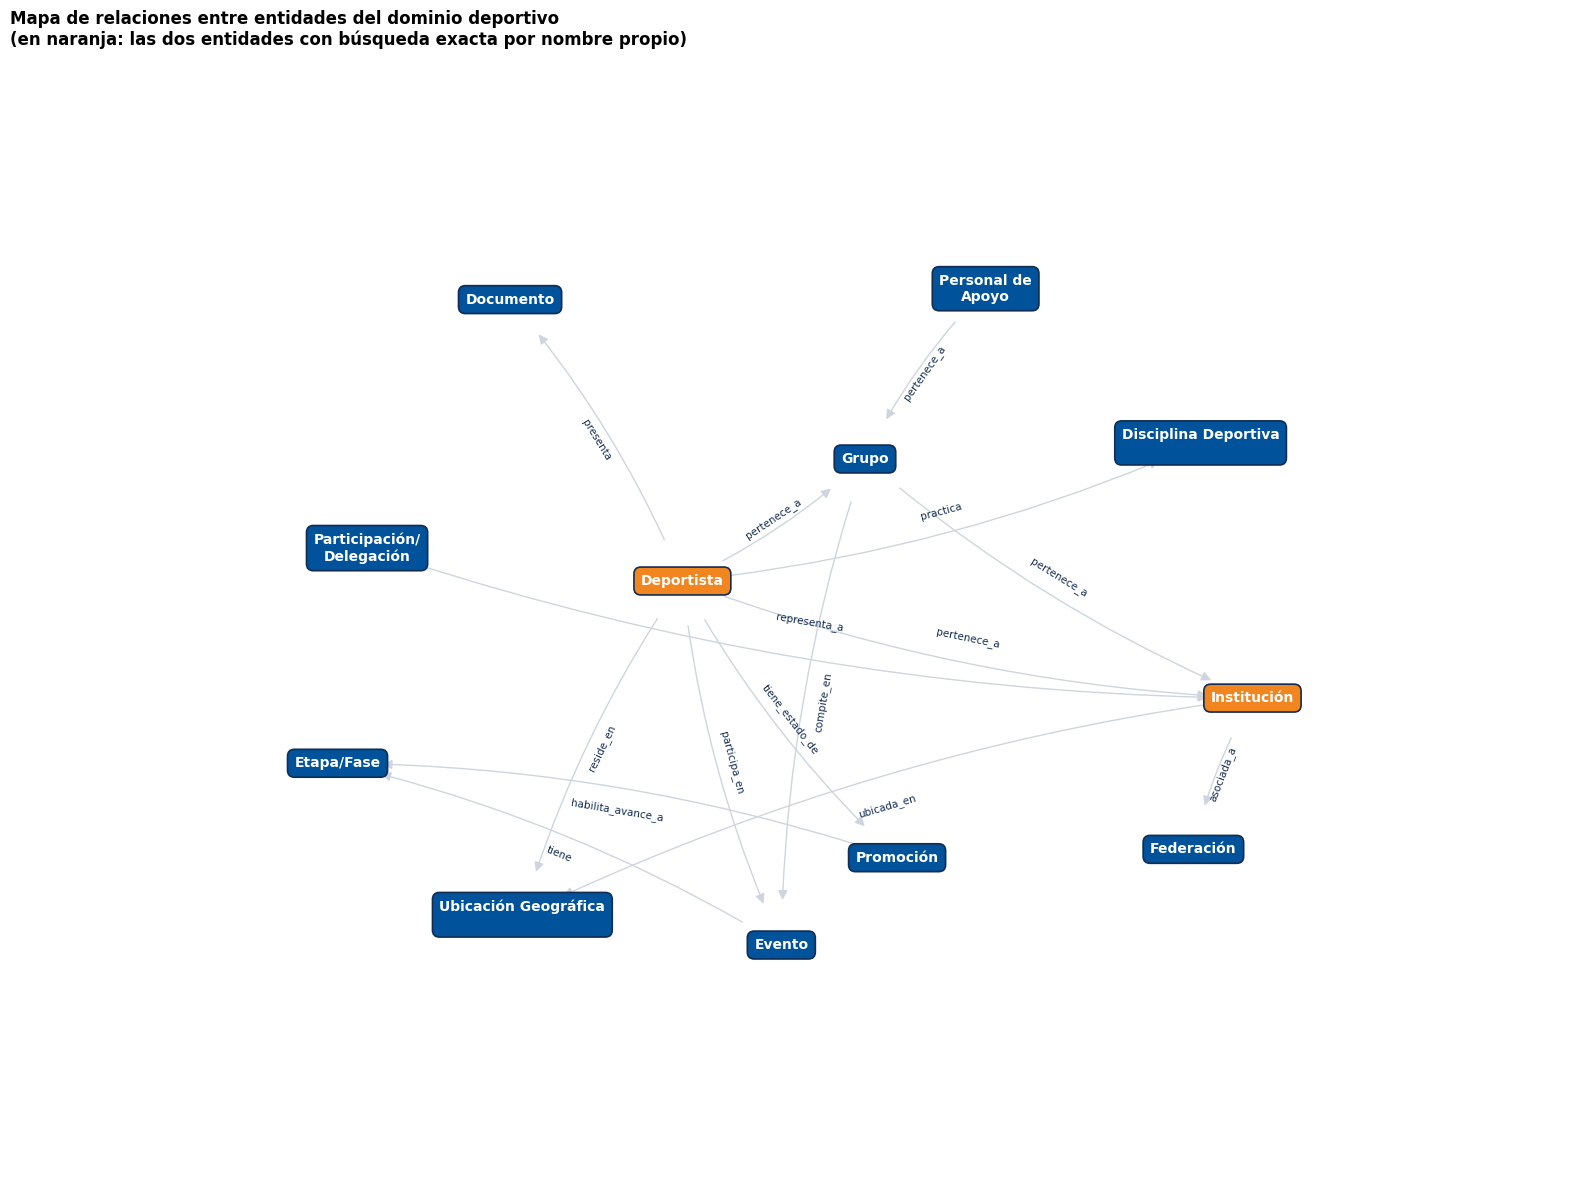

In [8]:
G_onto = nx.DiGraph()
for origen, rel, destino, tipo, _ in RELACIONES:
    G_onto.add_edge(origen, destino, label=rel)

fig, ax = plt.subplots(figsize=(16, 12))
pos = nx.spring_layout(G_onto, seed=7, k=2.1)

# nodos como cajas de texto (no círculos): evita que los nombres largos
# ("Personal de Apoyo", "Disciplina Deportiva") se corten en los bordes.
# las etiquetas largas se parten en dos líneas y clip_on=False evita que
# el texto quede recortado por los límites del eje cerca de los bordes
# de la figura (bug visual detectado: letras blancas cortadas a la mitad).
def _partir_etiqueta(nombre, max_chars=14):
    if len(nombre) <= max_chars:
        return nombre
    palabras = nombre.replace("/", "/ ").split(" ")
    linea1, linea2 = [], []
    destino = linea1
    largo = 0
    for palabra in palabras:
        if largo > len(nombre) / 2 and destino is linea1:
            destino = linea2
        destino.append(palabra.strip())
        largo += len(palabra)
    return " ".join(linea1).strip() + "\n" + " ".join(linea2).strip()

for nodo, (x, y) in pos.items():
    es_nombre_propio = nodo in ("Deportista", "Institución")
    ax.text(x, y, _partir_etiqueta(nodo), fontsize=10, fontweight="bold",
            color="white", ha="center", va="center", zorder=3, clip_on=False,
            bbox=dict(boxstyle="round,pad=0.5",
                      facecolor=NARANJA if es_nombre_propio else AZUL,
                      edgecolor=AZUL_OSC, linewidth=1.2))

nx.draw_networkx_edges(G_onto, pos, edge_color=GRIS_BORDE, arrows=True,
                        arrowsize=14, connectionstyle="arc3,rad=0.08",
                        node_size=4200, ax=ax)
edge_labels = nx.get_edge_attributes(G_onto, "label")
nx.draw_networkx_edge_labels(G_onto, pos, edge_labels=edge_labels, font_size=7.5,
                               font_color=AZUL_OSC, bbox=dict(alpha=0), ax=ax)

ax.set_title("Mapa de relaciones entre entidades del dominio deportivo\n"
              "(en naranja: las dos entidades con búsqueda exacta por nombre propio)",
              loc="left", fontweight="bold")
ax.axis("off")
ax.margins(0.28)
plt.tight_layout()
plt.savefig(ONTO_DIR / "fig_mapa_relaciones.png", bbox_inches="tight")
plt.show()


**Versión en diagrama del mismo mapa de relaciones**, útil como
referencia visual compacta, complementaria a la figura generada arriba con
`networkx`:

![Mapa de relaciones entre entidades](../images/diagramas/diagrama_3_mapa_relaciones.png)

<details><summary>Fuente Mermaid de este diagrama</summary>

```{mermaid}
flowchart LR
    Deportista["Deportista"] -->|pertenece_a| Grupo["Grupo"]
    Deportista -->|pertenece_a| Institucion["Institución"]
    Deportista -->|participa_en| Evento["Evento"]
    Deportista -->|tiene_estado_de| Promocion["Promoción"]
    Deportista -->|practica| Disciplina["Disciplina Deportiva"]
    Deportista -->|reside_en| UbicacionGeo["Ubicación Geográfica"]
    Deportista -->|presenta| Documento["Documento"]
    Grupo -->|pertenece_a| Institucion
    Grupo -->|compite_en| Evento
    Evento -->|tiene| EtapaFase["Etapa/Fase"]
    Promocion -->|habilita_avance_a| EtapaFase
    Institucion -->|ubicada_en| UbicacionGeo
    Institucion -->|asociada_a| Federacion["Federación"]
    PersonalApoyo["Personal de Apoyo"] -->|pertenece_a| Grupo
    Participacion["Participación/Delegación"] -->|representa_a| Institucion

    classDef nombrePropio fill:#F18520,color:#fff,stroke:#122C52,stroke-width:1px;
    classDef contexto fill:#00529B,color:#fff,stroke:#122C52,stroke-width:1px;
    class Deportista,Institucion nombrePropio;
    class Grupo,Evento,EtapaFase,Promocion,UbicacionGeo,Disciplina,Documento,PersonalApoyo,Participacion,Federacion contexto;
```

</details>


## 6. Conceptos de búsqueda prioritarios

Se listan los conceptos que con mayor probabilidad escribiría un usuario
real, **empezando deliberadamente por la búsqueda de nombres propios**
—el caso de uso que se quiere reforzar en esta capa—, y se indica a qué
entidades y reportes debe mapear cada uno.

In [9]:
CONCEPTOS_BUSQUEDA = [
    ("Buscar por el nombre de un deportista específico (ej. \"Andrés Torres\")",
     ["Deportista"], ["Reporte Individual de Deportistas", "Reporte de Promoción de Deportistas"], "Alta"),
    ("Buscar por el nombre de una institución específica (ej. un colegio)",
     ["Institución"], ["Reporte de Instituciones", "Reporte de Grupos"], "Alta"),
    ("Estado de promoción o avance de etapa de un deportista",
     ["Promoción", "Etapa/Fase", "Deportista"], ["Reporte de Promoción de Deportistas"], "Alta"),
    ("Deportistas que pertenecen a un grupo determinado",
     ["Deportista", "Grupo"], ["Reporte de Grupos"], "Alta"),
    ("Deportistas por categoría, disciplina o modalidad deportiva",
     ["Disciplina Deportiva", "Deportista"], ["Reporte Individual de Deportistas"], "Media"),
    ("Deportistas o instituciones por región, departamento o municipio",
     ["Ubicación Geográfica"], ["Reporte de Instituciones", "Reporte Individual de Deportistas"], "Media"),
    ("Documentos pendientes, rechazados o aprobados de un deportista",
     ["Documento", "Deportista"], ["Reporte de Documentación de Deportistas"], "Alta"),
    ("Personal de apoyo (entrenadores, acompañantes) de un grupo o evento",
     ["Personal de Apoyo", "Grupo"], ["Reporte de Personal de Apoyo"], "Alta"),
    ("Participación o intención de participación de una institución",
     ["Participación/Delegación", "Institución"], ["Reporte de Participación"], "Media"),
    ("Cumplimiento de metas de cobertura por región",
     ["Ubicación Geográfica"], ["Reporte de Progreso y Cumplimiento de Metas"], "Media"),
    ("Métricas agregadas por federación deportiva",
     ["Federación"], ["Reporte sobre Métricas por Federación Deportiva"], "Baja"),
    ("Fases o etapas de un evento específico",
     ["Evento", "Etapa/Fase"], ["Reporte de Promoción de Deportistas"], "Media"),
    ("Deportistas con alguna condición de inclusión (discapacidad, comunidad indígena, etc.)",
     ["Deportista"], ["Reporte Individual de Deportistas"], "Baja"),
    ("Resumen general del estado de un evento (tipo tablero de control)",
     ["Evento"], ["Reporte sobre Resumen del Tablero de Control"], "Media"),
]

tabla_conceptos = pd.DataFrame(CONCEPTOS_BUSQUEDA,
    columns=["Concepto de búsqueda", "Entidades involucradas", "Reportes a los que mapea", "Prioridad"])
tabla_conceptos


,Concepto de búsqueda,Entidades involucradas,Reportes a los que mapea,Prioridad
0,Buscar por el nombre de un deportista específi...,[Deportista],"[Reporte Individual de Deportistas, Reporte de...",Alta
1,Buscar por el nombre de una institución especí...,[Institución],"[Reporte de Instituciones, Reporte de Grupos]",Alta
2,Estado de promoción o avance de etapa de un de...,"[Promoción, Etapa/Fase, Deportista]",[Reporte de Promoción de Deportistas],Alta
3,Deportistas que pertenecen a un grupo determinado,"[Deportista, Grupo]",[Reporte de Grupos],Alta
4,"Deportistas por categoría, disciplina o modali...","[Disciplina Deportiva, Deportista]",[Reporte Individual de Deportistas],Media
5,"Deportistas o instituciones por región, depart...",[Ubicación Geográfica],"[Reporte de Instituciones, Reporte Individual ...",Media
6,"Documentos pendientes, rechazados o aprobados ...","[Documento, Deportista]",[Reporte de Documentación de Deportistas],Alta
7,"Personal de apoyo (entrenadores, acompañantes)...","[Personal de Apoyo, Grupo]",[Reporte de Personal de Apoyo],Alta
8,Participación o intención de participación de ...,"[Participación/Delegación, Institución]",[Reporte de Participación],Media
9,Cumplimiento de metas de cobertura por región,[Ubicación Geográfica],[Reporte de Progreso y Cumplimiento de Metas],Media


**Los 14 conceptos agrupados por prioridad.** Los dos primeros en
prioridad Alta son, deliberadamente, los dos casos de búsqueda por nombre
propio que este documento quiso reforzar:

![Conceptos de búsqueda por prioridad](../images/diagramas/diagrama_4_conceptos_por_prioridad.png)

<details><summary>Fuente Mermaid de este diagrama</summary>

```{mermaid}
flowchart TD
    subgraph Alta["Prioridad Alta"]
        C1["Nombre de un deportista específico"]
        C2["Nombre de una institución específica"]
        C3["Estado de promoción / avance de etapa"]
        C4["Deportistas de un grupo"]
        C5["Documentos de un deportista"]
        C6["Personal de apoyo de un grupo o evento"]
    end
    subgraph Media["Prioridad Media"]
        C7["Deportistas por disciplina o categoría"]
        C8["Deportistas o instituciones por región"]
        C9["Participación de una institución"]
        C10["Cumplimiento de metas por región"]
        C11["Fases de un evento"]
        C12["Resumen tipo tablero de control"]
    end
    subgraph Baja["Prioridad Baja"]
        C13["Métricas por federación"]
        C14["Deportistas con condición de inclusión"]
    end

    classDef alta fill:#F18520,color:#fff,stroke:#122C52,stroke-width:1px;
    classDef media fill:#00529B,color:#fff,stroke:#122C52,stroke-width:1px;
    classDef baja fill:#9AA5B1,color:#fff,stroke:#122C52,stroke-width:1px;
    class C1,C2,C3,C4,C5,C6 alta;
    class C7,C8,C9,C10,C11,C12 media;
    class C13,C14 baja;
```

</details>


## 7. Propuesta de ontología ligera

Se estructura formalmente lo definido en las secciones anteriores en un
esquema de **clases**, **propiedades de datos** y **propiedades de
relación**, en formato YAML —liviano, legible y fácil de cargar por
cualquier componente del pipeline del buscador—.

In [10]:
ontologia = {"clases": {}}

for entidad in sorted(atributos_por_entidad):
    atributos = [c for c, _ in atributos_por_entidad[entidad].most_common(10)]
    ontologia["clases"][entidad] = {
        "sinonimos": SINONIMOS_ENTIDAD.get(entidad, []),
        "propiedades_de_datos": [
            {"nombre": a, "tipo_busqueda": "entidad_exacta_nombre_propio" if a in COLUMNAS_NOMBRE_PROPIO else "atributo_filtrable"}
            for a in atributos
        ],
    }

ontologia["relaciones"] = [
    {"origen": o, "relacion": r, "destino": d, "tipo": t}
    for o, r, d, t, _ in RELACIONES
]

ontologia["jerarquias"] = [
    {"padre": "Federación", "hijo": "Institución"},
    {"padre": "Institución", "hijo": "Grupo"},
    {"padre": "Grupo", "hijo": "Deportista"},
    {"padre": "Evento", "hijo": "Etapa/Fase"},
]

yaml_texto = yaml.dump(ontologia, allow_unicode=True, sort_keys=False, width=100)
print(yaml_texto[:1500])

with open(ONTO_DIR / "ontologia_suid.yaml", "w", encoding="utf-8") as f:
    f.write(yaml_texto)
print(f"\nOntología completa exportada a: {ONTO_DIR / 'ontologia_suid.yaml'}")


clases:
  Deportista:
    sinonimos:
    - atleta
    - jugador
    - competidor
    - participante deportivo
    propiedades_de_datos:
    - nombre: document_number
      tipo_busqueda: atributo_filtrable
    - nombre: full_name
      tipo_busqueda: entidad_exacta_nombre_propio
    - nombre: email
      tipo_busqueda: atributo_filtrable
    - nombre: first_last_name
      tipo_busqueda: atributo_filtrable
    - nombre: first_name
      tipo_busqueda: atributo_filtrable
    - nombre: document_type_name
      tipo_busqueda: atributo_filtrable
    - nombre: is_reinforcement
      tipo_busqueda: atributo_filtrable
    - nombre: document_type
      tipo_busqueda: atributo_filtrable
    - nombre: phone_number
      tipo_busqueda: atributo_filtrable
    - nombre: sex_name
      tipo_busqueda: atributo_filtrable
  Disciplina Deportiva:
    sinonimos:
    - deporte
    - categoría
    - modalidad
    propiedades_de_datos:
    - nombre: sport_name
      tipo_busqueda: atributo_filtrable
    - n

## 8. Metadatos estructurados por reporte (prioridad Alta y Media)

Para cada uno de los 9 reportes de prioridad Alta o Media, se construye un
bloque de metadatos listo para inyectar: qué entidades y relaciones
involucra, qué conceptos de negocio responde, qué atributos son
filtrables, y sus sinónimos. Este bloque es lo que se concatenaría junto a
la descripción semántica (ya generada en `EDA_SUID.ipynb`) antes de
convertir cada reporte en un documento indexable.

In [11]:
reportes_prioritarios = tabla_maestra[
    tabla_maestra["prioridad_de_indexacion"].isin(["Alta", "Media"])
]["reporte"].tolist()

def entidades_de_reporte(reporte):
    entidades = set()
    for col in columnas_por_reporte.get(reporte, {}):
        e = COLUMNA_A_ENTIDAD.get(col)
        if e:
            entidades.add(e)
    return sorted(entidades)

def relaciones_de_reporte(entidades):
    ents = set(entidades)
    return [f"{o} {r} {d}" for o, r, d, _, _ in RELACIONES if o in ents and d in ents]

def conceptos_de_reporte(reporte):
    return [c for c, _, reps, _ in CONCEPTOS_BUSQUEDA if reporte in reps]

metadatos_por_reporte = []
for reporte in reportes_prioritarios:
    entidades = entidades_de_reporte(reporte)
    atributos_filtrables = sorted({
        col for col in columnas_por_reporte.get(reporte, {})
        if COLUMNA_A_ENTIDAD.get(col) and col not in COLUMNAS_NOMBRE_PROPIO
    })[:12]
    sinonimos = sorted({s for e in entidades for s in SINONIMOS_ENTIDAD.get(e, [])})
    bloque = {
        "reporte": reporte,
        "entidades_principales": entidades,
        "relaciones_clave": relaciones_de_reporte(entidades),
        "conceptos_de_negocio": conceptos_de_reporte(reporte),
        "atributos_filtrables": atributos_filtrables,
        "sinonimos": sinonimos,
        "tiene_busqueda_por_nombre_propio": bool(
            set(columnas_por_reporte.get(reporte, {})) & COLUMNAS_NOMBRE_PROPIO
        ),
    }
    metadatos_por_reporte.append(bloque)

print(json.dumps(metadatos_por_reporte[0], indent=2, ensure_ascii=False))


{
  "reporte": "Reporte de Promoción de Deportistas",
  "entidades_principales": [
    "Deportista",
    "Disciplina Deportiva",
    "Documento",
    "Etapa/Fase",
    "Evento",
    "Grupo",
    "Institución",
    "Personal de Apoyo",
    "Promoción",
    "Ubicación Geográfica"
  ],
  "relaciones_clave": [
    "Deportista pertenece_a Grupo",
    "Deportista pertenece_a Institución",
    "Deportista participa_en Evento",
    "Deportista tiene_estado_de Promoción",
    "Deportista practica Disciplina Deportiva",
    "Deportista reside_en Ubicación Geográfica",
    "Deportista presenta Documento",
    "Grupo pertenece_a Institución",
    "Grupo compite_en Evento",
    "Evento tiene Etapa/Fase",
    "Promoción habilita_avance_a Etapa/Fase",
    "Institución ubicada_en Ubicación Geográfica",
    "Personal de Apoyo pertenece_a Grupo"
  ],
  "conceptos_de_negocio": [
    "Buscar por el nombre de un deportista específico (ej. \"Andrés Torres\")",
    "Estado de promoción o avance de etapa de u

In [12]:
out_json = ONTO_DIR / "metadatos_por_reporte.json"
with open(out_json, "w", encoding="utf-8") as f:
    json.dump(metadatos_por_reporte, f, indent=2, ensure_ascii=False)

n_con_nombre = sum(1 for m in metadatos_por_reporte if m["tiene_busqueda_por_nombre_propio"])
print(f"Metadatos generados para {len(metadatos_por_reporte)} reportes -> {out_json}")
print(f"De esos, {n_con_nombre} habilitan búsqueda exacta por nombre propio "
      f"(deportista y/o institución).")


Metadatos generados para 9 reportes -> ../data/ontologia_suid/metadatos_por_reporte.json
De esos, 7 habilitan búsqueda exacta por nombre propio (deportista y/o institución).


## 9. Cómo y cuándo usar esta capa en el buscador

Retomando el diagrama de flujo de la propuesta (Figura 1 de la
monografía: fuera de línea se indexa con metadatos de ontología; en línea,
la consulta se resuelve con BM25 y un recuperador denso, cuyas listas se
fusionan con RRF y un refuerzo por entidad detectada), esta capa se
conecta en tres puntos concretos:

1. **En la indexación (fuera de línea).** La descripción semántica de cada
   reporte (`EDA_SUID.ipynb`) se concatena con los `conceptos_de_negocio`
   y los `sinonimos` de este documento antes de calcular su
   representación vectorial. Esto amplía el vocabulario con el que el
   recuperador denso puede reconocer la intención de una consulta, incluso
   si el usuario no usa exactamente las mismas palabras que la
   descripción original.

2. **En la detección de entidades (en línea, antes de la fusión).** Los
   `atributos_filtrables` de cada reporte —y, de forma especial, las
   columnas marcadas como `entidad_exacta_nombre_propio`— alimentan
   directamente el componente de "Detección de entidad" del diagrama de
   flujo. Aquí es donde se resuelve el caso de uso central de este
   documento: cuando la consulta contiene un nombre propio (de deportista
   o de institución), el sistema debe reconocerlo por coincidencia exacta
   o aproximada, no esperar a que el modelo semántico lo "entienda".

3. **Como refuerzo en la fusión de resultados (RRF).** Cuando se detecta
   una entidad exacta, el reporte cuyos `atributos_filtrables` la incluyen
   recibe un realce suave en la fusión —el mismo mecanismo de *boost* ya
   definido en la propuesta—, sin descartar los resultados puramente
   semánticos.

**Advertencia de privacidad, importante para el caso de nombres
propios.** Para que la búsqueda por "Andrés Torres" funcione, el
componente de detección de entidades necesita comparar la consulta contra
un listado de nombres reales de deportistas o instituciones. Ese listado
**no debe confundirse con el corpus semántico** que se indexa con las
descripciones de los reportes (que, como se estableció desde el EDA
anterior, nunca contiene datos personales). Debe ser un componente
**separado**, de acceso controlado —un diccionario de resolución de
nombre a identificador interno—, consultado solo en el momento de
detectar la entidad, y no expuesto como parte del contenido semántico
indexado. Esta separación es la forma correcta de habilitar búsqueda por
nombre propio sin comprometer el principio de anonimización que se ha
mantenido durante todo el proyecto.


**Diagrama de la arquitectura híbrida con la separación de
privacidad.** En naranja, el único componente que puede tocar datos
personales (el diccionario nombre→identificador); en azul, todo lo que
compone el corpus semántico, que nunca contiene datos personales:

![Arquitectura híbrida con separación de privacidad](../images/diagramas/diagrama_5_arquitectura_hibrida_privacidad.png)

<details><summary>Fuente Mermaid de este diagrama</summary>

```{mermaid}
flowchart TD
    Q["Consulta en lenguaje natural<br/>ej. &quot;Andrés Torres&quot; o &quot;reporte de grupos&quot;"] --> ID["Detección de entidad e intención"]
    ID --> GAZ{"¿La consulta contiene<br/>un nombre propio?"}
    GAZ -- "Sí" --> LOOKUP["Diccionario nombre → identificador<br/>(componente separado, acceso controlado,<br/>ÚNICO punto con datos personales)"]
    LOOKUP --> BOOST["Refuerzo (boost) del reporte<br/>correspondiente en la fusión"]
    GAZ -- "No" --> SEM["Corpus semántico indexado<br/>(descripciones + conceptos + sinónimos,<br/>sin datos personales)"]
    SEM --> BM25["Recuperador BM25 (léxico)"]
    SEM --> DENSO["Recuperador denso (semántico)"]
    BM25 --> RRF["Fusión RRF"]
    DENSO --> RRF
    BOOST --> RRF
    RRF --> R["Resultados ordenados al usuario"]

    classDef pii fill:#F18520,color:#fff,stroke:#122C52,stroke-width:1px;
    classDef safe fill:#00529B,color:#fff,stroke:#122C52,stroke-width:1px;
    class LOOKUP pii;
    class SEM,BM25,DENSO safe;
```

</details>


## 10. Extensión: el dominio de Competencias

El EDA de reportes (`EDA_SUID.ipynb`, Sección 19) documentó un hallazgo
que cambia el alcance de esta ontología: **ninguna de las 744 consultas
históricas de Athena toca las tablas de competencias** (eventos, fases,
disciplinas, resultados) — no porque el dominio sea irrelevante, sino
porque nunca se expuso como reporte. La investigación de ese hallazgo
(`data/competencias_suid/README.md`, `mapeo_competencias.json`) mapeó a
fondo ese dominio con evidencia real del Glue Data Catalog y de Athena.
Esta sección incorpora esa evidencia a la ontología: dos entidades nuevas
—**Región (deportiva)** y **Competencia / Prueba Regional**— y sus
relaciones con las entidades ya existentes.

In [13]:
with open("../data/competencias_suid/mapeo_competencias.json", encoding="utf-8") as f:
    mapeo_competencias = json.load(f)

print("Regiones deportivas reales (8):", mapeo_competencias["regiones_reales"])
print("Fases reales (5):", mapeo_competencias["fases_reales"])
print("Combinaciones deporte x categoría únicas:", len(mapeo_competencias["deportes_x_categoria_unicos"]))
print("Eventos reales en producción:", len(mapeo_competencias["eventos_reales"]))
print()
ej = mapeo_competencias["ejemplo_busqueda_objetivo"]
print("Caso de uso objetivo:", ej["consulta_usuario"])
for comp in ej["componentes"]:
    print(f"  - {comp['concepto']}: {comp['valor_real']}  ({comp['fuente']})")


Regiones deportivas reales (8): ['Amazonía', 'Caribe 1', 'Caribe 2', 'Centro Oriente', 'Centro Sur', 'Eje Cafetero', 'Orinoquia', 'Pacífico']
Fases reales (5): ['Fase 1', 'Municipales', 'Departamentales', 'Regionales', 'Nacionales']
Combinaciones deporte x categoría únicas: 102
Eventos reales en producción: 4

Caso de uso objetivo: Atletismo Pre-Juvenil en Región Caribe 1
  - deporte + categoria: Atletismo / Pre Juvenil  (bronze_suid_events.disciplines.sport_name / category_name)
  - region: Caribe 1  (gold_suid.region_progress.region_name)
  - fase: Regionales  (bronze_suid_events.phases.name)


### 10.1 Las dos entidades nuevas

- **Región (deportiva).** Agrupación de 33 departamentos en 8
  macro-regiones usadas específicamente para organizar la fase
  "Regionales" de una competencia (`Caribe 1`, `Caribe 2`, `Centro
  Oriente`, `Centro Sur`, `Eje Cafetero`, `Amazonía`, `Orinoquia`,
  `Pacífico`). Es un concepto distinto de "Ubicación Geográfica"
  (departamento/municipio de residencia o de una institución): mismo tipo
  de dato geográfico, pero con un propósito de negocio específico —
  organizar competencias, no ubicar personas o instituciones—, por lo que
  se modela como entidad propia en vez de mezclarla con los atributos ya
  existentes de Ubicación Geográfica.
- **Competencia / Prueba Regional.** Entidad **sintética** —no existe como
  fila en ninguna tabla—: la intersección de una disciplina (deporte +
  categoría), una fase, y (cuando la fase es "Regionales") una región.
  Exactamente el caso de uso objetivo de este documento: *"Atletismo
  Pre-Juvenil en Región Caribe 1"* se arma en tiempo de indexación
  concatenando estos tres valores reales, no leyendo un campo único.

In [14]:
# Entidad "Región (deportiva)"
SINONIMOS_ENTIDAD["Región (deportiva)"] = [
    "macrorregión deportiva", "zona deportiva", "región de competencia",
]
ontologia["clases"]["Región (deportiva)"] = {
    "sinonimos": SINONIMOS_ENTIDAD["Región (deportiva)"],
    "propiedades_de_datos": [
        {"nombre": "region_name", "tipo_busqueda": "atributo_filtrable"},
    ],
}

# Entidad sintética "Competencia / Prueba Regional"
SINONIMOS_ENTIDAD["Competencia / Prueba Regional"] = [
    "prueba", "prueba regional", "competencia deportiva", "encuentro deportivo",
]
ontologia["clases"]["Competencia / Prueba Regional"] = {
    "tipo": "entidad_sintetica",
    "formula_de_construccion": "{sport_name} {category_name} en Región {region_name} ({fase})",
    "sinonimos": SINONIMOS_ENTIDAD["Competencia / Prueba Regional"],
    "propiedades_de_datos": [
        {"nombre": "sport_name", "tipo_busqueda": "atributo_filtrable"},
        {"nombre": "category_name", "tipo_busqueda": "atributo_filtrable"},
        {"nombre": "fase", "tipo_busqueda": "atributo_filtrable"},
        {"nombre": "region_name", "tipo_busqueda": "atributo_filtrable"},
    ],
}

# Nuevas relaciones con entidades ya existentes
NUEVAS_RELACIONES = [
    ("Competencia / Prueba Regional", "corresponde_a", "Disciplina Deportiva", "composición",
     "El deporte y la categoría de una competencia provienen de bronze_suid_events.disciplines."),
    ("Competencia / Prueba Regional", "ocurre_en", "Región (deportiva)", "ubicación",
     "La fase Regionales agrupa la competencia por región, no por departamento."),
    ("Competencia / Prueba Regional", "corresponde_a", "Etapa/Fase", "temporal",
     "Cada competencia pertenece a una fase del evento (Municipales, Departamentales, Regionales, Nacionales)."),
    ("Competencia / Prueba Regional", "parte_de", "Evento", "jerárquica",
     "Toda competencia ocurre dentro de un evento macro (unos Juegos Nacionales, unos Suramericanos, etc.)."),
    ("Región (deportiva)", "agrupa_a", "Ubicación Geográfica", "jerárquica",
     "Cada región agrupa varios departamentos (33 departamentos -> 8 regiones, evidencia real en departamento_a_region.csv)."),
]
RELACIONES.extend(NUEVAS_RELACIONES)
ontologia["relaciones"].extend([
    {"origen": o, "relacion": r, "destino": d, "tipo": t} for o, r, d, t, _ in NUEVAS_RELACIONES
])

tabla_relaciones_competencias = pd.DataFrame(
    NUEVAS_RELACIONES,
    columns=["Entidad origen", "Relación", "Entidad destino", "Tipo", "Evidencia / justificación"])
tabla_relaciones_competencias


,Entidad origen,Relación,Entidad destino,Tipo,Evidencia / justificación
0,Competencia / Prueba Regional,corresponde_a,Disciplina Deportiva,composición,El deporte y la categoría de una competencia p...
1,Competencia / Prueba Regional,ocurre_en,Región (deportiva),ubicación,La fase Regionales agrupa la competencia por r...
2,Competencia / Prueba Regional,corresponde_a,Etapa/Fase,temporal,Cada competencia pertenece a una fase del even...
3,Competencia / Prueba Regional,parte_de,Evento,jerárquica,Toda competencia ocurre dentro de un evento ma...
4,Región (deportiva),agrupa_a,Ubicación Geográfica,jerárquica,Cada región agrupa varios departamentos (33 de...


### 10.2 Conceptos de búsqueda nuevos

Los dos conceptos que motivaron toda esta investigación, ahora
formalizados junto a los 14 ya existentes:

In [15]:
CONCEPTOS_BUSQUEDA_COMPETENCIAS = [
    ("Buscar una competencia específica por deporte, categoría y región "
     "(ej. \"Atletismo Pre-Juvenil en Región Caribe 1\")",
     ["Competencia / Prueba Regional", "Disciplina Deportiva", "Región (deportiva)"],
     ["Sin reporte existente hoy — hallazgo Sección 19 del EDA"], "Alta"),
    ("Buscar los resultados de un deportista específico en una competencia "
     "(ej. \"Andrés Camargo en Atletismo Pre-Juvenil Caribe 1\")",
     ["Deportista", "Competencia / Prueba Regional"],
     ["Sin reporte existente hoy — hallazgo Sección 19 del EDA"], "Alta"),
]
CONCEPTOS_BUSQUEDA.extend(CONCEPTOS_BUSQUEDA_COMPETENCIAS)

tabla_conceptos_competencias = pd.DataFrame(CONCEPTOS_BUSQUEDA_COMPETENCIAS,
    columns=["Concepto de búsqueda", "Entidades involucradas", "Reportes a los que mapea", "Prioridad"])
tabla_conceptos_competencias


,Concepto de búsqueda,Entidades involucradas,Reportes a los que mapea,Prioridad
0,"Buscar una competencia específica por deporte,...","[Competencia / Prueba Regional, Disciplina Dep...",[Sin reporte existente hoy — hallazgo Sección ...,Alta
1,Buscar los resultados de un deportista específ...,"[Deportista, Competencia / Prueba Regional]",[Sin reporte existente hoy — hallazgo Sección ...,Alta


**Nota de privacidad (reafirmada con evidencia nueva).** En
`bronze_suid_events.result_entries`, las columnas `participant_name` y
`group_name` están tipadas `VARBINARY` con longitud fija de 25 bytes en
todas las filas muestreadas — un indicio fuerte de que ya están
**cifradas a nivel de columna** en la propia capa bronce. Esto confirma,
con evidencia directa (no solo como recomendación de diseño), la
separación de privacidad de la Sección 9: incluso si se quisiera indexar
"resultados de Andrés Camargo en una competencia", la tabla de resultados
no expone el nombre en texto plano — la resolución de nombre debe seguir
pasando por el diccionario de acceso controlado, nunca por esta tabla.

In [16]:
catalogo_competencias = pd.DataFrame([
    {
        "Entidad": "Región (deportiva)",
        "Sinónimos": ", ".join(SINONIMOS_ENTIDAD["Región (deportiva)"]),
        "Atributos principales (observados en datos reales)": "region_name",
        "Reportes donde aparece con más fuerza": "Sin reporte existente (hallazgo Sección 19 del EDA)",
    },
    {
        "Entidad": "Competencia / Prueba Regional",
        "Sinónimos": ", ".join(SINONIMOS_ENTIDAD["Competencia / Prueba Regional"]),
        "Atributos principales (observados en datos reales)": "sport_name, category_name, fase, region_name (entidad sintética)",
        "Reportes donde aparece con más fuerza": "Sin reporte existente (hallazgo Sección 19 del EDA)",
    },
])
catalogo_entidades = pd.concat([catalogo_entidades, catalogo_competencias], ignore_index=True)
catalogo_entidades.to_csv(ONTO_DIR / "catalogo_entidades.csv", index=False)
print(f"Catálogo de entidades extendido a {len(catalogo_entidades)} entidades (12 originales + 2 de competencias).")
catalogo_entidades


Catálogo de entidades extendido a 13 entidades (12 originales + 2 de competencias).


,Entidad,Sinónimos,Atributos principales (observados en datos reales),Reportes donde aparece con más fuerza
0,Deportista,"atleta, jugador, competidor, participante depo...","document_number, **full_name** (nombre propio)...","Reporte de Promoción de Deportistas, Reporte d..."
1,Disciplina Deportiva,"deporte, categoría, modalidad","sport_name, category_name, discipline_name, sp...","Reporte de Grupos, Reporte de Promoción de Dep..."
2,Documento,"soporte, certificado, requisito documental","document_status, document_date, uploaded_docum...","Reporte de Documentación de Deportistas, Repor..."
3,Etapa/Fase,"fase, ronda, nivel de competencia","current_stage, stage_sequence, discipline_status","Reporte de Grupos, Reporte de Promoción de Dep..."
4,Evento,"competencia, torneo, juegos, certamen deportivo","event_code, event_phases_count, event_name, ev...","Reporte de Promoción de Deportistas, Reporte d..."
5,Grupo,"delegación de grupo, equipo, conjunto de depor...","group_name, group_status, total_athletes","Reporte de Promoción de Deportistas, Reporte d..."
6,Institución,"colegio, escuela, club, entidad educativa o de...","inst_department_name, inst_municipality_name, ...","Reporte de Promoción de Deportistas, Reporte d..."
7,Participación/Delegación,"intención de participación, inscripción de del...","delegation_name, delegation_code, modified_at","Reporte de Participación, Reporte de Cambios e..."
8,Personal de Apoyo,"entrenador, acompañante, cuerpo técnico","role_name, participant_role","Reporte de Promoción de Deportistas, Reporte d..."
9,Promoción,"avance de etapa, ascenso de categoría, clasifi...","status, estado_promocion","Reporte de Promoción de Deportistas, Reporte d..."


In [17]:
yaml_texto = yaml.dump(ontologia, allow_unicode=True, sort_keys=False, width=100)
with open(ONTO_DIR / "ontologia_suid.yaml", "w", encoding="utf-8") as f:
    f.write(yaml_texto)
print(f"Ontología re-exportada (extendida) a: {ONTO_DIR / 'ontologia_suid.yaml'}")
print(f"Clases totales: {len(ontologia['clases'])} | Relaciones totales: {len(ontologia['relaciones'])}")


Ontología re-exportada (extendida) a: ../data/ontologia_suid/ontologia_suid.yaml
Clases totales: 13 | Relaciones totales: 20


**Cómo se arma la competencia objetivo, en un diagrama:**

![Construcción de la competencia objetivo](../images/diagramas/diagrama_6_construccion_competencia.png)

<details><summary>Fuente Mermaid de este diagrama</summary>

```{mermaid}
flowchart LR
    D["Disciplina Deportiva<br/>sport_name = Atletismo<br/>category_name = Pre Juvenil"] --> COMP(("Competencia /<br/>Prueba Regional"))
    F["Etapa/Fase<br/>fase = Regionales"] --> COMP
    R["Región (deportiva)<br/>region_name = Caribe 1"] --> COMP
    COMP --> RES["'Atletismo Pre-Juvenil<br/>en Región Caribe 1'"]
    COMP -.->|parte_de| EV["Evento<br/>(ej. Juegos Intercolegiados<br/>Nacionales 2026)"]

    classDef entrada fill:#00529B,color:#fff,stroke:#122C52,stroke-width:1px;
    classDef sintetica fill:#F18520,color:#fff,stroke:#122C52,stroke-width:1px;
    classDef resultado fill:#122C52,color:#fff,stroke:#122C52,stroke-width:1px;
    class D,F,R,EV entrada;
    class COMP sintetica;
    class RES resultado;
```

</details>


## 11. Conclusiones

1. El dominio deportivo se modela con 12 entidades de negocio, todas con
   atributos respaldados por columnas realmente observadas en las
   consultas del sistema, no por suposición.
2. **Deportista** e **Institución** son las dos entidades con atributos de
   nombre propio, y son el punto de apalancamiento directo para resolver
   búsquedas literales por nombre —el caso de uso que este documento
   quiso reforzar explícitamente—.
3. Se definieron 15 relaciones entre entidades, con evidencia directa en
   al menos una de ellas (Deportista–Promoción–Etapa) proveniente del
   propio SQL analizado en el caso de estudio anterior.
4. Los 9 reportes de prioridad Alta y Media ya cuentan con un bloque de
   metadatos estructurados —entidades, relaciones, conceptos, atributos
   filtrables y sinónimos— listo para inyectarse en el pipeline.
5. La ontología completa quedó exportada en un archivo YAML único,
   reutilizable por cualquier componente del sistema sin depender de este
   cuaderno.
6. Se dejó documentado, de forma explícita, que la búsqueda por nombre
   propio requiere un componente de resolución de nombres separado del
   corpus semántico, por las mismas razones de privacidad que han guiado
   el proyecto desde la extracción inicial de datos.
7. **Se extendió la ontología con el dominio de Competencias** (Sección
   10), a partir del hallazgo del EDA de que ese dominio tiene volumen
   real considerable pero cero cobertura de reporte. Se agregaron 2
   entidades (Región deportiva, y la entidad sintética Competencia/Prueba
   Regional), 5 relaciones nuevas y 2 conceptos de búsqueda de prioridad
   Alta —incluyendo el caso de uso objetivo que motivó esta extensión:
   *"Atletismo Pre-Juvenil en Región Caribe 1"*—. La ontología exportada
   ahora cubre 14 entidades en total.

## Archivos generados

- `data/ontologia_suid/catalogo_entidades.csv` (14 entidades: 12
  originales + 2 de Competencias)
- `data/ontologia_suid/ontologia_suid.yaml` (extendido con Competencias)
- `data/ontologia_suid/metadatos_por_reporte.json`
- `data/ontologia_suid/fig_mapa_relaciones.png`
- `data/ontologia_suid/diagramas/diagrama_6_construccion_competencia.png`
- Insumo reutilizado: `data/competencias_suid/mapeo_competencias.json`
